In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy.integrate import trapezoid

In [2]:
#we will be using LOFAR's 54MHz band, hence 
lambda_cm = 555.5 #cm 
cm_to_eVin = 5.068 *1e4 
lambda_natural = lambda_cm *cm_to_eVin 

In [3]:
# radius range
r = np.logspace(-6, 3, 1000)
#np.sqrt(z**2 + b**2) 

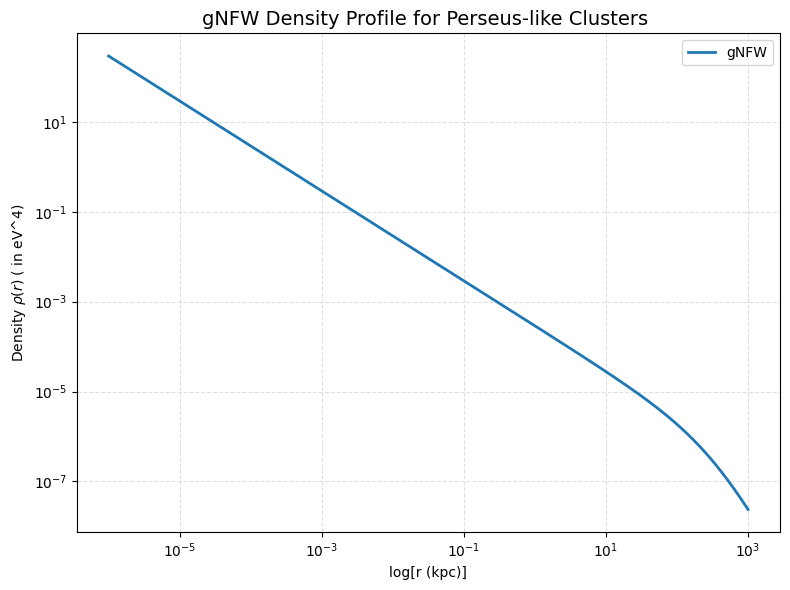

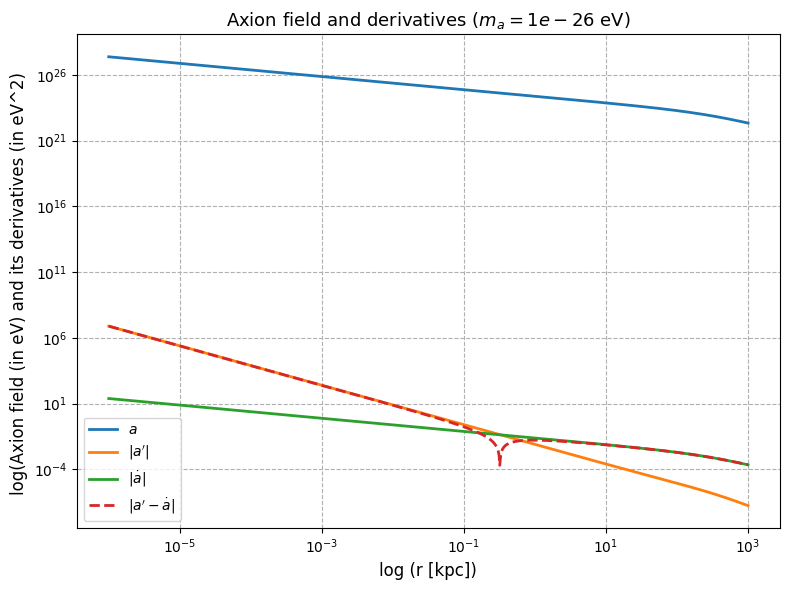

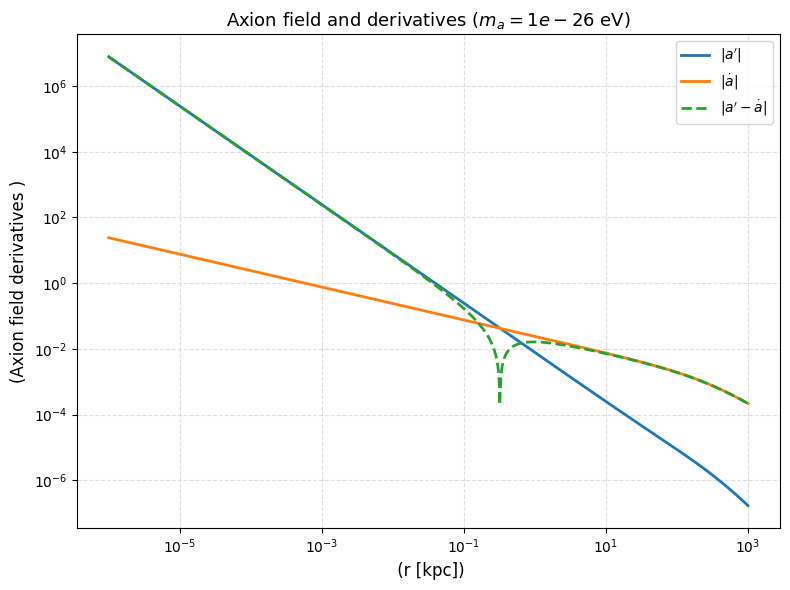

In [4]:
#NFW profile, axion field and its field derivatives

#parameters , reference https://arxiv.org/abs/1109.2834v2, table 4
#it is 2.2 *1e15 M_dot / Mpc3GeVcm3_to_eV4 = 7.1e-6
rho_0 = 0.73 *1e-6     # eV^4

r_s =  400 #kpc

#ONE SIDED 
# gNFW
def gnfw(r, rho_0, r_s):
    x = r / r_s
    return rho_0 / ((x) * (1 + x)**(2))
#hence we get density profile in terms of natural units ( eV^4) 


# densities
rho1 = gnfw(r, rho_0, r_s)  #eV4

# plot
plt.figure(figsize=(8,6))

plt.loglog(r, rho1,linewidth=2,label='gNFW') #ev4 vs kpc 


plt.xlabel(r'log[r (kpc)]')
plt.ylabel(r'Density $\rho(r)$ ( in eV^4)')
plt.title('gNFW Density Profile for Perseus-like Clusters ', fontsize=14)

plt.legend()

plt.grid(True,which='both',linestyle='--',alpha=0.4)

plt.tight_layout()
plt.show()




#AXION FIELD ( all of this is b=0 , so z=r , that we'll need to change for imapct parameters ) 

m_a = 1e-26#ev

kpc_to_eV_inv = 1.56 * 1e26
rs_natural  = r_s * kpc_to_eV_inv

def a(r):
    rho = gnfw(r, rho_0, r_s)
    return np.sqrt(2 * rho) / m_a    #a(r) in eV

def a_dot(r):
    x = r / r_s
    return ( -1 * np.sqrt(2 * rho_0) * (x)**-0.5 * (1 + x)**-1  )  # in eV2  ( the -1 is beacuse d(cos) = -sin )

def a_prime(r):
    x = r / r_s
    return (  ( np.sqrt(2 * rho_0) / ( m_a * rs_natural ) ) * ((-0.5 * (x)**-1.5 * (1 + x)**-1) + (-1* (x)**-0.5 * (1 + x)**-2)))
#a , a_dot and a_prime are functions of z 


plt.figure(figsize=(8, 6))

plt.loglog(r,a(r),lw=2,label=r'$a$')
plt.loglog(r,np.abs(a_prime(r)),'-',lw=2,label=r'$|a^\prime|$')
plt.loglog(r,np.abs(a_dot(r)),'-',lw=2,label=r'$|\dot a|$')
plt.loglog(r,np.abs(a_prime(r) - a_dot(r)),'--',lw=2,label=r'$|a^\prime - \dot a|$')


plt.xlabel('log (r [kpc])', fontsize=12)
plt.ylabel('log(Axion field (in eV) and its derivatives (in eV^2) ', fontsize=12)

plt.title(rf'Axion field and derivatives ($m_a={m_a:.0e}$ eV)',fontsize=13)

plt.grid(True, which='both',linestyle='--')

plt.legend()
plt.tight_layout()
plt.show()


#PLOTTING THE DERIVATIVES ONLY

plt.figure(figsize=(8, 6))

plt.loglog(r,np.abs(a_prime(r)),'-',lw=2,label=r'$|a^\prime|$')
plt.loglog(r,np.abs(a_dot(r)),'-',lw=2,label=r'$|\dot a|$')
plt.loglog(r,np.abs(a_prime(r) - a_dot(r)),'--',lw=2,label=r'$|a^\prime - \dot a|$')


plt.xlabel(' (r [kpc])', fontsize=12)
plt.ylabel('(Axion field derivatives )', fontsize=12)

plt.title(rf'Axion field and derivatives ($m_a={m_a:.0e}$ eV)',fontsize=13)

plt.grid(True, which='both',
         linestyle='--',
         alpha=0.4)

plt.legend()
plt.tight_layout()
plt.show()

In [5]:
#Beta model of electron density 
beta = 0.75
rc =300 #kpc
n0 = 20 #cm-3

def ne(r):
    return n0 * ( ( 1 + (r/rc)**2)**(-1.5 * beta))

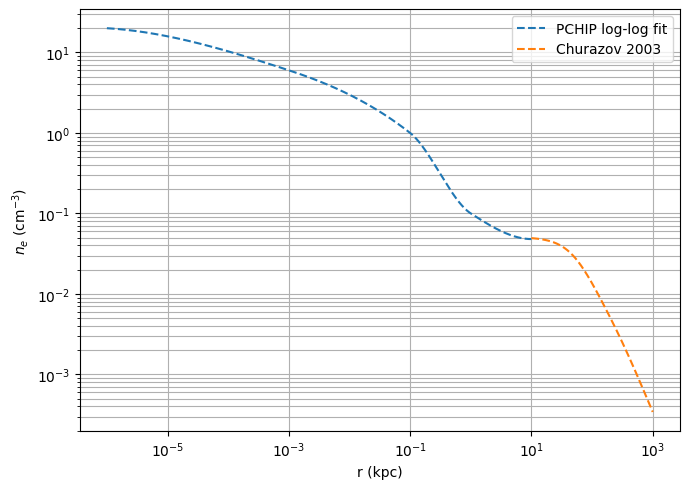

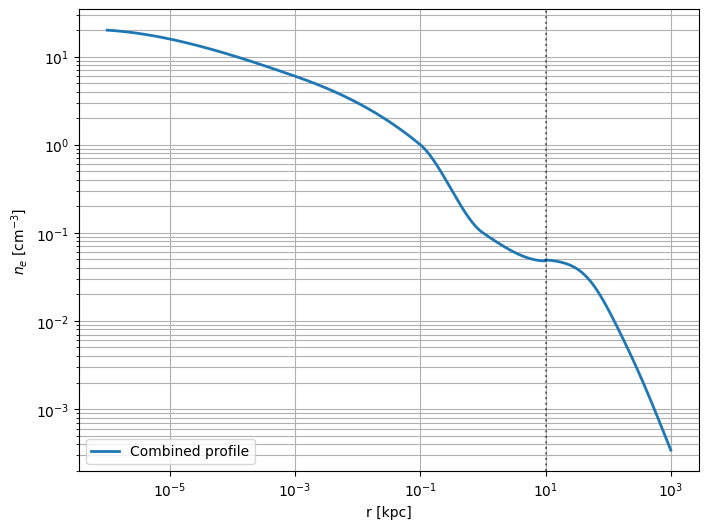

In [4]:
#custom electron density 
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
#Kam 2026 and Yao 2017
from scipy.interpolate import PchipInterpolator
from scipy.integrate import trapezoid

x = np.array([1e-6, 1e-3, 1e-1, 1, 1e1])#kpc
y = np.array([20, 6, 1, 0.1, 4.8e-2]) #cm-3

# interpolate in log-log space
logx = np.log10(x)
logy = np.log10(y)

interp = PchipInterpolator(logx, logy)
#PCHIP stands for Piecewise Cubic Hermite Interpolating Polynomial.

def n_core(r):
    r_array = np.asarray(r)
    return 10**interp(np.log10(r_array))
    
xfit = np.logspace(logx.min(), logx.max(), 2000)
yfit = 10**interp(np.log10(xfit))
distance = np.logspace(1,3,2000)
# plt.figure(figsize=(8,6))
# n_core(xfit) == 10**interp(np.log10(xfit))

#Churasov 
def n_churasov(r):
    r_array = np.asarray(r)
    return ( (4.6*1e-2) / (1 + (r_array/60)**2)**1.18  + (4.8*1e-3) / (1 + (r_array/200)**2)**0.87  )


plt.figure(figsize=(7,5))
plt.loglog(xfit, yfit, '--', label='PCHIP log-log fit')
plt.loglog(distance, n_churasov(distance), '--', label='Churazov 2003')

plt.xlabel(r'r (kpc)')
plt.ylabel(r'$n_e$ (cm$^{-3}$)')
plt.grid(True, which='both')
plt.legend()
plt.tight_layout()
plt.show()

def ne(r):
    r_array = np.asarray(r)
    return np.where(r_array < 10, n_core(r), n_churasov(r))

#function of z, b 

plt.figure(figsize=(8,6))
plt.loglog(r, ne(r), lw=2, label='Combined profile')


plt.axvline(10, color='k', ls=':', alpha=0.5)

plt.xlabel('r [kpc]')
plt.ylabel(r'$n_e$ [cm$^{-3}$]')
plt.grid(True, which='both')
plt.legend()
plt.show()


In [18]:
#aDM birefringence from time delay 

#time delay 
#del_t = g_agg * lambda^3 * e^2 / ( 4 * (2pi)^3  * me * epsilon)  * integration of ( ne * (a_prime - a_dot) *dz)

#prefactor 
g_agg_Normal =  6.6 * 1e-11 #GeV−1
g_agg = g_agg_Normal * 1e-9 #eV-1
cm_inv_to_ev =7.68 * 1e-15 #eV3.


 #Kam 2026 at zero, PCHIP interpolation for initial then Churazov 2004 for later
    
def integrand(z):
    return ( ne(z) * cm_inv_to_ev * (np.abs(a_prime(z) - a_dot(z))) )
    
from scipy.integrate import simpson
area = simpson(integrand(r), x=r * kpc_to_eV_inv) #since my dx is in kpc right, but a dot a prime ave r/rs so kpc doesnt come into picture but the dz in my integration 
#this will give me an area as a function of b 


c = 1
#4pi epsilon = 1 in natural units
e_sq = 0.0854**2 #in natual units
me = 5.11 *1e5 #eV
prefactor = (g_agg /4)* (lambda_natural**3) * (2*np.pi*np.pi) * ( e_sq /me)
 
DeltaT=  prefactor * area  
#as a fucntion of b 

#time in seconds 
eVinv_to_s = 6.58e-16
T_sec = DeltaT * eVinv_to_s


#axion birefringence delta a = c * time delay / (2 *lambda)
DeltaA = (c/(2*lambda_natural)) * DeltaT
wrapped_DeltaA = np.degrees(DeltaA) % 180 

A_SI = T_sec * (3e8) / (2 * 5.55 )
A_deg = np.degrees(A_SI) % 180

print("Time delay in natural units", DeltaT)
print("Time delay in seconds", T_sec)
print("DeltaA in natural units", DeltaA)
#convert a to degrees
print("angle of brief in degrees from DeltaT calculations", wrapped_DeltaA)

print("axion biref in degrees", A_deg)

Time delay in natural units 31445552351.21659
Time delay in seconds 2.069117344710052e-05
DeltaA in natural units 558.591424883458
angle of brief in degrees from DeltaT calculations 144.93111802109706
axion biref in degrees 0.9976132976989902


In [13]:
# https://arxiv.org/pdf/astro-ph/0602622   centre of the 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

# Inner magnetic field, sech2 plot

# Bp = 0.978      # microGauss
# rp = 7.29       # kpc

# # # #a reference density
# # # #n_ref = ne(30.0)


# # B_inner = Bp / np.cosh(r/rp)**2
# # #B0 = Bp / np.cosh(30/rp)**2
# # B_outer = B0 * (ne(r)/n0)**0.67

# #combined 
# B_total = np.where(r < 30.0, B_inner, B_outer)


#just eta model 
B0 =4 #muG
eta = 0.67
beta =0.75
rc = 300 

B_total = B0 * ((1+ (r/rc)**2)**(-3*beta*eta/2))

integrand = ne(r) * B_total

RM = 812 * trapezoid( integrand, x=r)  # kpc -> pc)

print(f"RM = {RM:.2f} rad/m^2")


plt.figure(figsize=(8,5))
plt.plot(r, B_total)
plt.axvline(30, ls='--', color='k')
plt.xlabel("r [kpc]")
plt.ylabel(r"$B_\parallel$ [$\mu$G]")
plt.grid(True, which="both")
plt.show()

plt.figure(figsize=(8,5))
plt.loglog(r, B_total)
plt.axvline(30, ls='--', color='k')
plt.xlabel("r [kpc]")
plt.ylabel(r"$B_\parallel$ [$\mu$G]")
plt.grid(True, which="both")
plt.show()

plt.figure(figsize=(8,5))
plt.loglog(r, ne(r))
plt.xlabel("r [kpc]")
plt.ylabel(r"$n_e$ [cm$^{-3}$]")
plt.grid(True, which="both")
plt.show()

plt.figure(figsize=(8,5))
plt.loglog(r, integrand)
plt.xlabel("r [kpc]")
plt.ylabel(r"$n_e B_\parallel$")
plt.grid(True, which="both")
plt.show()

#faraday rotation 

FR = lambda_cm**2 * 1e-4 * RM
print("Faraday rotation angle =", FR) 

wrapped_FR = np.degrees(FR) % 180
print("Faraday rotation  =", wrapped_FR) 

NameError: name 'r' is not defined

## RM v/s Lambda_sq

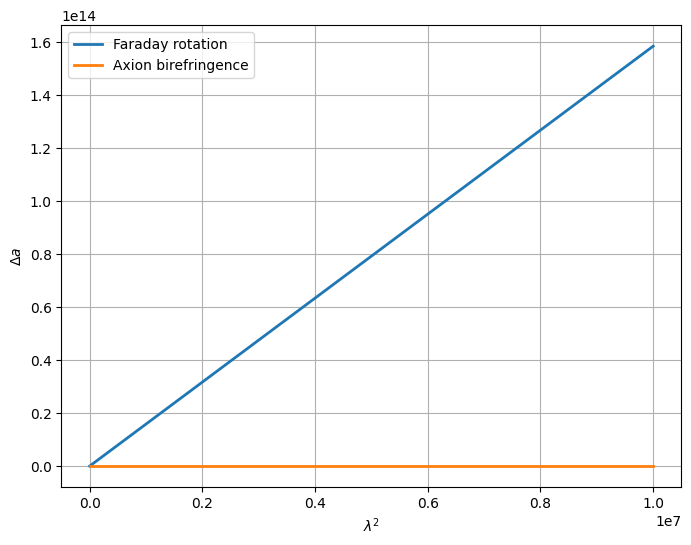

Faraday slope: 15844627.154380977
Axion slope: 8.939514506475218e-13


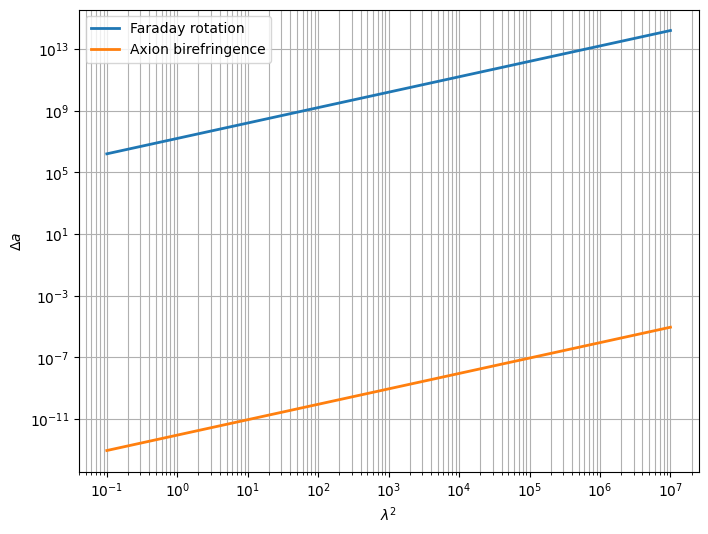

Faraday slope: 0.9999999999999997
Axion slope: 1.0000000000000002


In [10]:
# Faraday rotation angle with varying freq
lambda_sq = np.logspace(-1, 7, 1000) # 100 khz = 3000 m hence lamda_sq = 9e6
FR_changing = lambda_sq * RM   #Psi_0 term value unknown, taking it as 0

#aDM biref with varying frequency 

DeltaA_changing = (g_agg /4) * (2*np.pi*np.pi) * (e_sq / me) * (c/2) * area * lambda_sq


plt.figure(figsize=(8,6))
plt.plot(lambda_sq, FR_changing, lw=2, label='Faraday rotation')
plt.plot(lambda_sq, DeltaA_changing, lw=2, label='Axion birefringence')
plt.xlabel(r'$\lambda^2$')
plt.ylabel(r'$\Delta a$')
plt.grid(True, which='both')
plt.legend()
plt.show()

def linear_slope(x, y):
    return np.polyfit(x, y, 1)[0]
print("Faraday slope:",  linear_slope(lambda_sq, FR_changing))
print("Axion slope:", linear_slope(lambda_sq, DeltaA_changing))

plt.figure(figsize=(8,6))
plt.loglog(lambda_sq, FR_changing, lw=2, label='Faraday rotation')
plt.loglog(lambda_sq, DeltaA_changing, lw=2, label='Axion birefringence')
plt.xlabel(r'$\lambda^2$')
plt.ylabel(r'$\Delta a$')
plt.grid(True, which='both')
plt.legend()
plt.show()

# log-log slope fit
def slope(x, y):
    return np.polyfit(np.log10(x), np.log10(y), 1)[0]
    

print("Faraday slope:",  slope(lambda_sq, FR_changing))
print("Axion slope:", slope(lambda_sq, DeltaA_changing))

## CHANGING b = IMPACT PARAMETER 


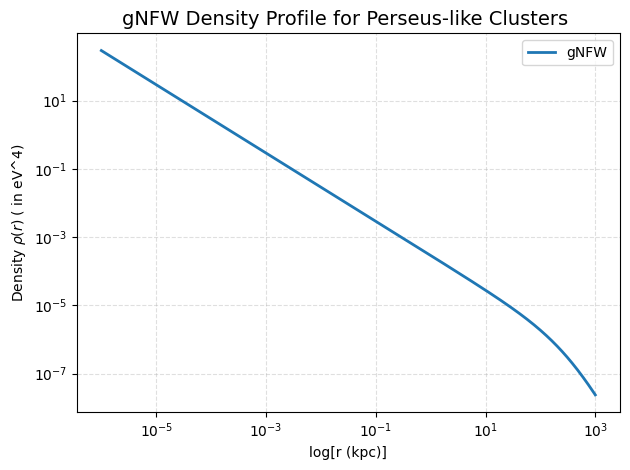

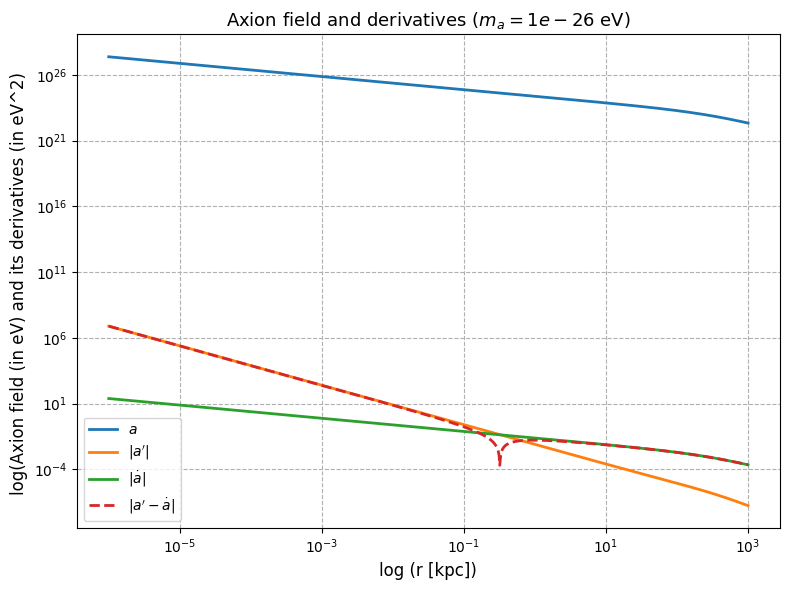

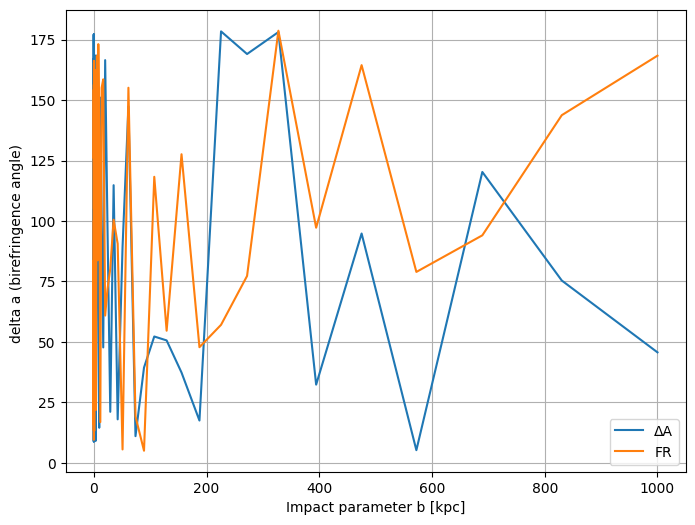

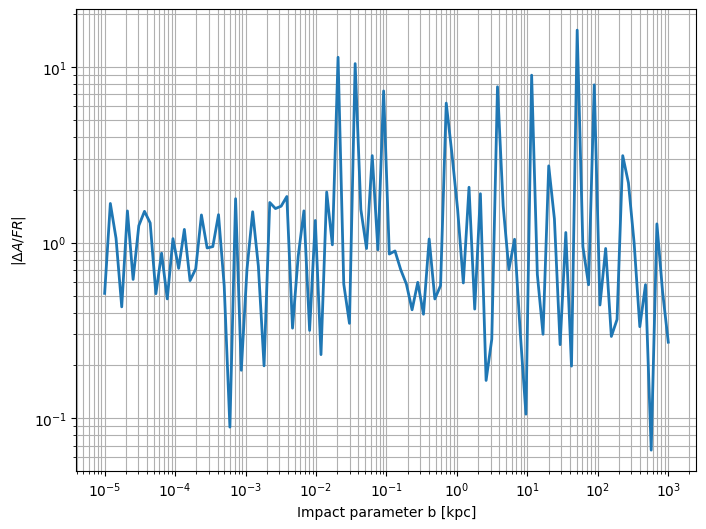

In [23]:
z = np.logspace(-6, 3, 2000)  # kpc


rho_0 = 0.73e-6   # eV^4
r_s   = 400       # kpc

m_a = 1e-26       # eV

kpc_to_eV_inv = 1.56e26
rs_natural = r_s * kpc_to_eV_inv

g_agg = 6.6e-11 * 1e-9  # eV^-1

cm_inv_to_ev = 7.68e-15
e_sq = 0.0854**2
me = 5.11e5

lambda_cm = 555.5 
lambda_natural = lambda_cm * 5.067e4

def r_los(z, b):
    return np.sqrt(z**2 + b**2)

#nfw
def gnfw(r, rho_0, r_s):
    x = r / r_s
    return rho_0 / (x * (1 + x)**2)


plt.loglog(r, gnfw(r, rho_0, r_s),linewidth=2,label='gNFW') #ev4 vs kpc 

plt.xlabel(r'log[r (kpc)]')
plt.ylabel(r'Density $\rho(r)$ ( in eV^4)')
plt.title('gNFW Density Profile for Perseus-like Clusters ', fontsize=14)

plt.legend()
plt.grid(True,which='both',linestyle='--',alpha=0.4)
plt.tight_layout()
plt.show()


#axion field and derivatives 
def a(r):
    rho = gnfw(r, rho_0, r_s)
    return np.sqrt(2 * rho) / m_a

def a_dot(r):
    x = r / r_s
    return -np.sqrt(2 * rho_0) * x**(-0.5) * (1 + x)**(-1)

def a_prime(r):
    x = r / r_s
    return (np.sqrt(2 * rho_0) / (m_a * rs_natural)) * (
        -0.5 * x**(-1.5) * (1 + x)**(-1)
        -1.0 * x**(-0.5) * (1 + x)**(-2)
    )

plt.figure(figsize=(8, 6))

plt.loglog(r,a(r),lw=2,label=r'$a$')
plt.loglog(r,np.abs(a_prime(r)),'-',lw=2,label=r'$|a^\prime|$')
plt.loglog(r,np.abs(a_dot(r)),'-',lw=2,label=r'$|\dot a|$')
plt.loglog(r,np.abs(a_prime(r) - a_dot(r)),'--',lw=2,label=r'$|a^\prime - \dot a|$')


plt.xlabel('log (r [kpc])', fontsize=12)
plt.ylabel('log(Axion field (in eV) and its derivatives (in eV^2) ', fontsize=12)

plt.title(rf'Axion field and derivatives ($m_a={m_a:.0e}$ eV)',fontsize=13)

plt.grid(True, which='both',linestyle='--')

plt.legend()
plt.tight_layout()
plt.show()


# #ne model
# x = np.array([1e-6, 1e-3, 1e-1, 1, 1e1])
# y = np.array([20, 6, 1, 0.1, 4.8e-2])

# interp = PchipInterpolator(np.log10(x), np.log10(y))

# def n_core(r):
#     return 10**interp(np.log10(r))

# def n_churasov(r):
#     return (
#         (4.6e-2)/(1+(r/60)**2)**1.18 +
#         (4.8e-3)/(1+(r/200)**2)**0.87
#     )

# def ne(r):
#     return np.where(r < 10, n_core(r), n_churasov(r))
n0 = 20 #cm-3 
rc = 300 #kpc 
beta = 0.75

def ne(r):
    return n0 * ((1 + (r/rc)**2)**(-1.5 *beta))




#integrating along the LOS for aDM birefringence/time delay and Faraday rotation/Rotation measure  


def integrand_axion(z, b):
    r = r_los(z, b)
    return ne(r) * cm_inv_to_ev * np.abs(a_prime(r) - a_dot(r))
    

def integrand_RM(z, b, B0=4, eta=0.67, n0=20):

    r = r_los(z, b)

    B = B0 * (ne(r) / n0)**eta

    return ne(r) * B

# they will be functions of b 

def axion_area(b):

    vals = integrand_axion(z, b)
    return 2 * simpson(vals, x=z * kpc_to_eV_inv)

def RM_of_b(b, B0=1.0, eta=0.5):

    vals = integrand_RM(z, b, B0=B0, eta=eta)
    return 2 * 812 * simpson(vals, x=z)

#hence we get 
def DeltaT(b):

    area = axion_area(b)
    prefactor = (g_agg / 4) * lambda_natural**3 * (2*np.pi*np.pi) * (e_sq / me)
    
    return prefactor * area


def DeltaA(b):   #in radians 
    return DeltaT(b) / (2 * lambda_natural)
    
def DeltaA_wrapped (b):   #in degrees 
    return np.degrees(DeltaA(b)) %180

def FR_wrapped(b): #in degrees 

    
    return np.degrees(FR(b)) %180 


def FR(b): #in radians 

    RM = RM_of_b(b)
    return lambda_cm**2 * 1e-4 * RM  


# print(DeltaT)
# print(T_sec)
# print(DeltaA)
# print(FR)
#convert a to degrees

#varying with impact parameter 
b_vals = np.logspace(-5, 3, 100)

DeltaA_vals = np.array([DeltaA_wrapped(b) for b in b_vals])
FR_vals     = np.array([FR_wrapped(b) for b in b_vals])



plt.figure(figsize=(8,6))
plt.plot(b_vals, np.abs(DeltaA_vals), label="ΔA")
plt.plot(b_vals, np.abs(FR_vals), label="FR")
plt.xlabel("Impact parameter b [kpc]")
plt.ylabel("delta a (birefringence angle) ")
plt.grid(True, which="both")
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.loglog(b_vals, np.abs(DeltaA_vals / FR_vals), lw=2)
plt.xlabel("Impact parameter b [kpc]")
plt.ylabel(r"$|\Delta A / FR|$")
plt.grid(True, which="both")
plt.show()

